<a href="https://colab.research.google.com/github/fadeeva/Bayesian_Statistics_and_Quantitative_Finance/blob/main/01_Bayesian_estimation_of_volatility_with_unknown_drift/Bayesian_estimation_of_volatility_with_unknown_drift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
from scipy import stats

import datetime as dt
import yfinance as yf

import arviz as az
import pymc as pm

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Bayesian estimation of volatility with unknown drift

## Data

In [2]:
ticker = '^GSPC'
start = dt.datetime(2023, 1, 1)
interval = '1d'
data = yf.download(ticker, start=start, interval=interval, auto_adjust=True)
data.to_csv('data.csv')

[*********************100%***********************]  1 of 1 completed


In [3]:
df = pd.read_csv('data.csv', parse_dates=True, header=[0,1], index_col=0)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2023-01-03,3824.139893,3878.459961,3794.330078,3853.290039,3959140000
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000


In [4]:
df.shape

(835, 5)

In [5]:
df['log_return'] = np.log(df['Close'].div(df['Close'].shift(1)))
df.dropna(axis=0, inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,log_return
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,
2023-01-04,3852.969971,3873.159912,3815.770020,3840.360107,4414080000,0.007511
2023-01-05,3808.100098,3839.739990,3802.419922,3839.739990,3893450000,-0.011714
2023-01-06,3895.080078,3906.189941,3809.560059,3823.370117,3923560000,0.022584
2023-01-09,3892.090088,3950.570068,3890.419922,3910.820068,4311770000,-0.000768
2023-01-10,3919.250000,3919.830078,3877.290039,3888.570068,3851030000,0.006954


In [ ]:
df.shape

(833, 6)

## Classical volatility estimation

In [ ]:
df['log_return'].std()

0.009415452073096025

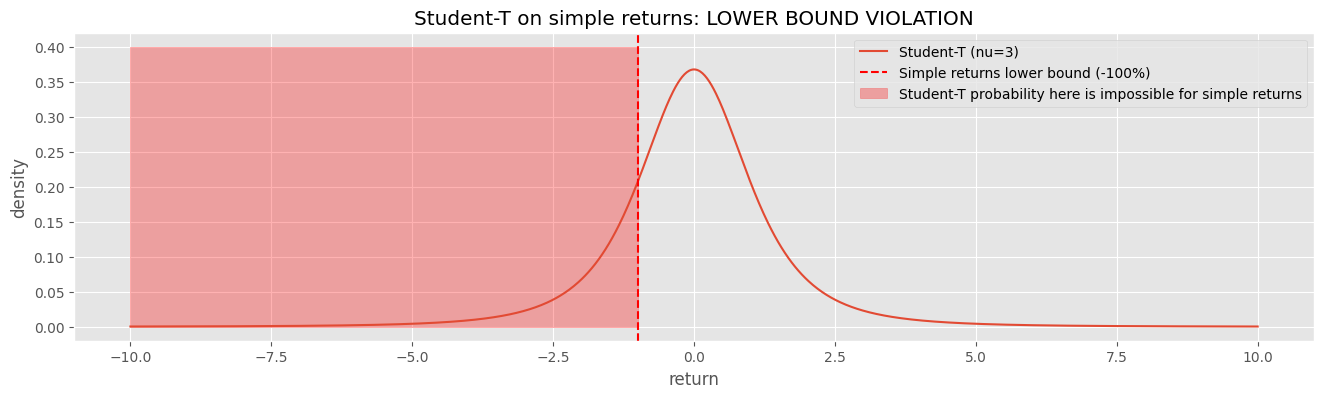

In [ ]:
# Почему нужен log_return

from scipy.stats import t

# Студент-T определён на всей числовой прямой (−∞,+∞)
x = np.linspace(-10, 10, 1000)
plt.figure(figsize=(16, 4))
plt.plot(x, t.pdf(x, df=3), label='Student-T (nu=3)')

# Простые доходности ограничены снизу -1
plt.axvline(x=-1, color='r', linestyle='--', label='Simple returns lower bound (-100%)')
plt.fill_between([-10, -1], 0, 0.4, color='r', alpha=0.3, label='Student-T probability here is impossible for simple returns')

plt.xlabel('return')
plt.ylabel('density')
plt.title('Student-T on simple returns: LOWER BOUND VIOLATION')
plt.legend()

## Bayesian Estimation

### Normal Distribution

In [33]:
with pm.Model() as normal_model:
    mu = pm.Normal('mu', mu=0, sigma=0.01)
    sigma = pm.HalfNormal('sigma', sigma=0.02)

    returns_obs = pm.Normal('returns_obs', mu=mu, sigma=sigma, observed=df['log_return'])

    trace = pm.sample(2000, tune=1000, chains=4, return_inferencedata=True)

az.plot_trace(trace)

In [7]:
normal_samples = trace.posterior['sigma'].values.flatten()

### Laplace's Distribution

In [34]:
with pm.Model() as laplace_model:
    mu = pm.Normal('mu', mu=0, sigma=0.01)
    b = pm.HalfNormal('b', sigma=0.02)  # scale parameter

    returns_obs = pm.Laplace('returns_obs', mu=mu, b=b, observed=df['log_return'])

    trace = pm.sample(2000, tune=1000, chains=4, return_inferencedata=True)

az.plot_trace(trace)

In [9]:
b_samples = trace.posterior['b'].values.flatten()
laplace_samples = b_samples * np.sqrt(2) # daily

### Student Distribution

In [35]:
with pm.Model() as student_model:
    mu = pm.Normal('mu', mu=0, sigma=.01) # drift
    sigma = pm.HalfNormal('sigma', sigma=.05) # volatility
    nu = pm.Gamma("nu", alpha=2, beta=0.1)  # degrees of freedom, tail thickness

    returns = pm.StudentT('returns', mu=mu, sigma=sigma, nu=nu, observed=df['log_return'])

    trace = pm.sample(2000, tune=1000, chains=4, return_inferencedata=True)

az.plot_trace(trace)

In [ ]:
summary = az.summary(trace, hdi_prob=0.94)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.001,0.000,0.001,0.002,0.000,0.00,6094.0,5435.0,1.0
nu,4.425,0.713,3.246,5.826,0.011,0.01,4270.0,5185.0,1.0
sigma,0.007,0.000,0.006,0.007,0.000,0.00,4484.0,5348.0,1.0


In [11]:
nu_samples = trace.posterior['nu'].values.flatten()
sigma_samples = trace.posterior['sigma'].values.flatten()

# Корректировка: true volatility = sigma * sqrt(nu/(nu-2))
# Защита от nu <= 2 (иначе бесконечная дисперсия)
nu_safe = np.maximum(nu_samples, 2.01)
student_samples = sigma_samples * np.sqrt(nu_safe / (nu_safe - 2))

### Result

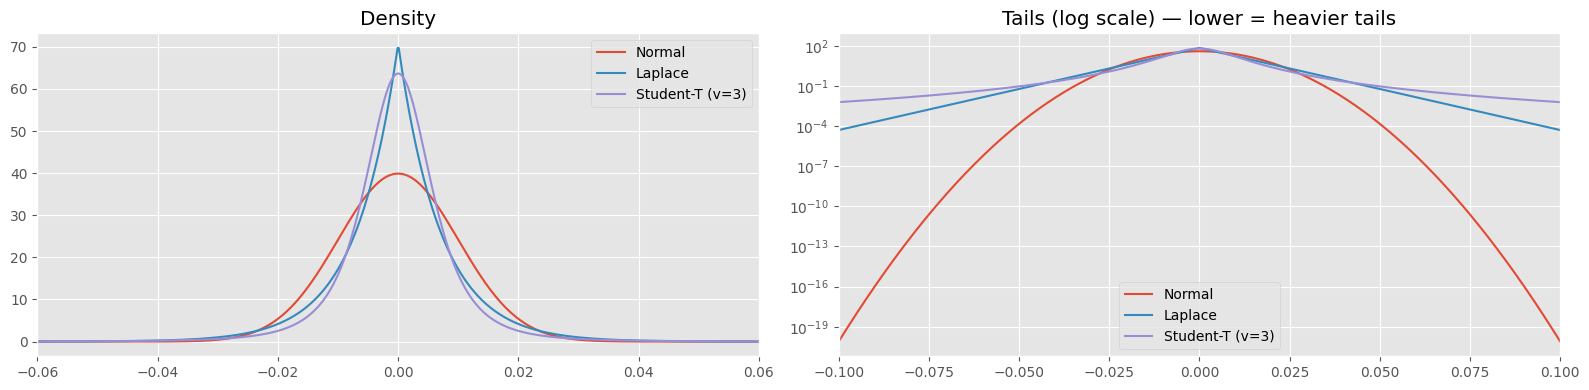

In [14]:
from scipy.stats import t, laplace, norm

# Параметры, чтобы все распределения имели одинаковую волатильность (std = 0.01)
target_std = 0.01

# Laplace: b = sigma / sqrt(2) = 0.01 / 1.414 = 0.00707
laplace_b = target_std / np.sqrt(2)

# Student-T: sigma = target_std / sqrt(nu/(nu-2))
nu = 3
student_sigma = target_std / np.sqrt(nu/(nu-2))

x = np.linspace(-0.1, 0.1, 1000)

plt.figure(figsize=(16, 4))

# Subplot 1: плотность (центр)
plt.subplot(1, 2, 1)
plt.plot(x, norm.pdf(x, 0, target_std), label='Normal')
plt.plot(x, laplace.pdf(x, 0, laplace_b), label='Laplace')
plt.plot(x, t.pdf(x, nu, scale=student_sigma), label=f'Student-T (v={nu})')
plt.xlim(-0.06, 0.06)
plt.title('Density')
plt.legend()

# Subplot 2: хвосты (лог-масштаб)
plt.subplot(1, 2, 2)
plt.semilogy(x, norm.pdf(x, 0, target_std), label='Normal')
plt.semilogy(x, laplace.pdf(x, 0, laplace_b), label='Laplace')
plt.semilogy(x, t.pdf(x, nu, scale=student_sigma), label=f'Student-T (v={nu})')
plt.xlim(-0.1, 0.1)
plt.title('Tails (log scale) — lower = heavier tails')
plt.legend()

plt.tight_layout()

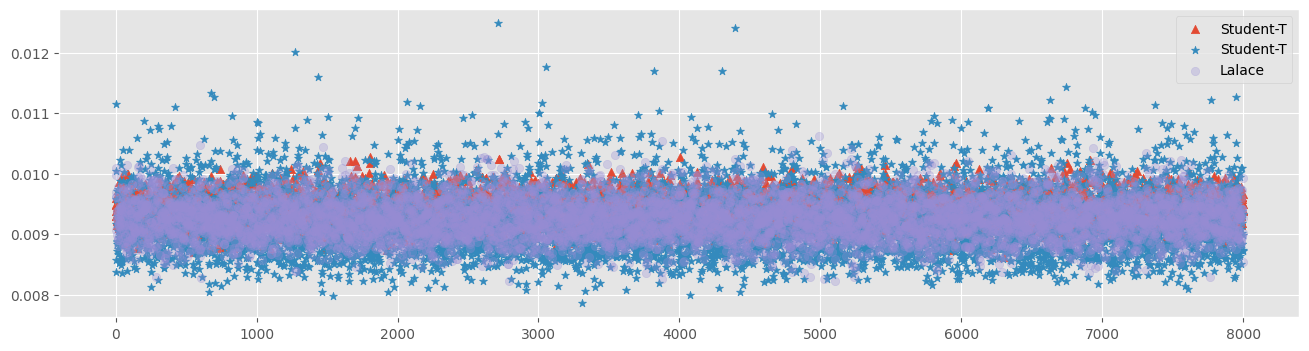

In [16]:
x = np.arange(8_000)
plt.figure(figsize=(16, 4))
plt.scatter(x, normal_samples, label='Student-T', marker='^')
plt.scatter(x, student_samples, label='Student-T', marker='*')
plt.scatter(x, laplace_samples, label='Lalace', alpha=.3)
plt.legend()

/tmp/ipykernel_10244/504006777.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot,


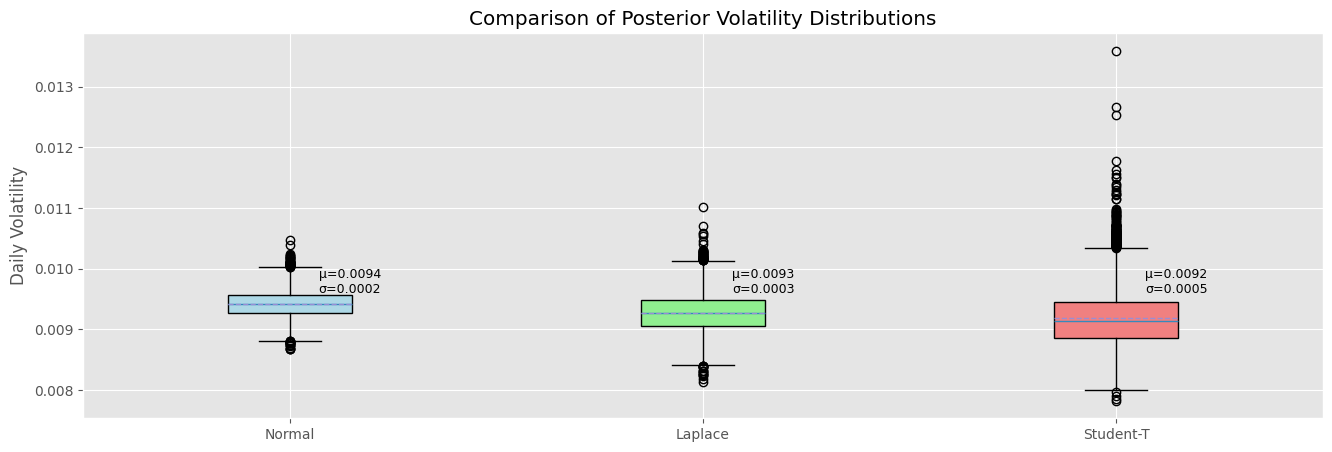

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

data_to_plot = [normal_samples, laplace_samples, student_samples]
bp = ax.boxplot(data_to_plot,
                labels=['Normal', 'Laplace', 'Student-T'],
                patch_artist=True,
                showmeans=True,
                meanline=True)

colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Daily Volatility')
ax.set_title('Comparison of Posterior Volatility Distributions')

means = [np.mean(v) for v in data_to_plot]
stds = [np.std(v) for v in data_to_plot]

for i, (mean, std, label) in enumerate(zip(means, stds, ['Normal', 'Laplace', 'Student-T']), 1):
    ax.text(i+.07, 0.0096, f'μ={mean:.4f}\nσ={std:.4f}', fontsize=9)

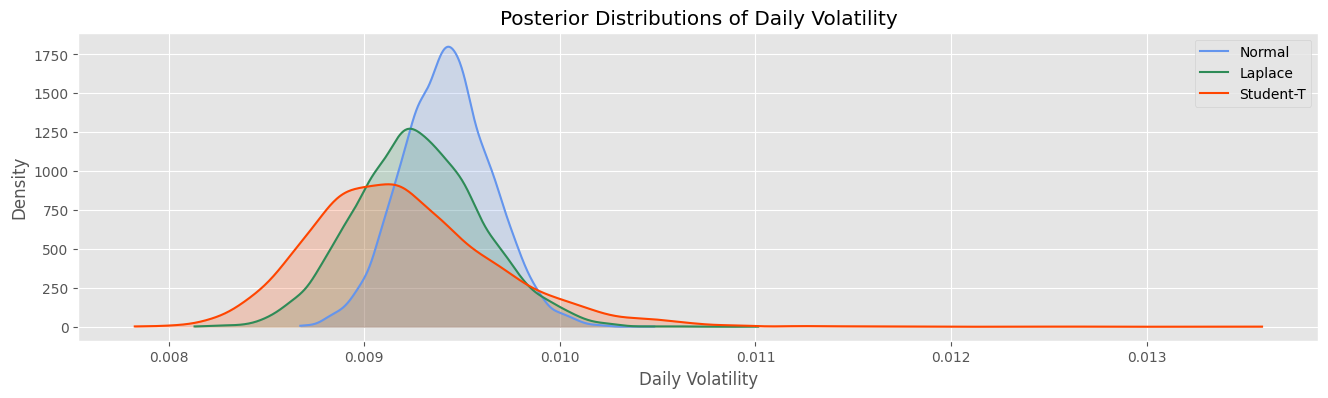

In [ ]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(16, 4))

for vol, label, color in zip([normal_samples, laplace_samples, student_samples],
                             ['Normal', 'Laplace', 'Student-T'],
                             ['cornflowerblue', 'seagreen', 'orangered']):
    kde = gaussian_kde(vol)
    x = np.linspace(vol.min(), vol.max(), 1000)
    ax.plot(x, kde(x), label=label, color=color)
    ax.fill_between(x, kde(x), alpha=0.2, color=color)

ax.set_xlabel('Daily Volatility')
ax.set_ylabel('Density')
ax.set_title('Posterior Distributions of Daily Volatility')
ax.legend()

In [22]:
comparison_df = pd.DataFrame({
    'MODEL': ['Normal', 'Laplace', 'Student-T'],
    'mean': [np.mean(normal_samples), np.mean(laplace_samples), np.mean(student_samples)],
    'std': [np.std(normal_samples), np.std(laplace_samples), np.std(student_samples)],
    'median': [np.median(normal_samples), np.median(laplace_samples), np.median(student_samples)],
    '95% HDI lower': [
        np.percentile(normal_samples, 2.5),
        np.percentile(laplace_samples, 2.5),
        np.percentile(student_samples, 2.5)
    ],
    '95% HDI upper': [
        np.percentile(normal_samples, 97.5),
        np.percentile(laplace_samples, 97.5),
        np.percentile(student_samples, 97.5)
    ],
    'IQR': [
        np.percentile(normal_samples, 75) - np.percentile(normal_samples, 25),
        np.percentile(laplace_samples, 75) - np.percentile(laplace_samples, 25),
        np.percentile(student_samples, 75) - np.percentile(student_samples, 25)
    ]
})

comparison_df

,MODEL,mean,std,median,95% HDI lower,95% HDI upper,IQR
0,Normal,0.009420,0.000228,0.009417,0.008989,0.009871,0.000311
1,Laplace,0.009283,0.000317,0.009277,0.008686,0.009913,0.000427
2,Student-T,0.009205,0.000490,0.009149,0.008425,0.010340,0.000615


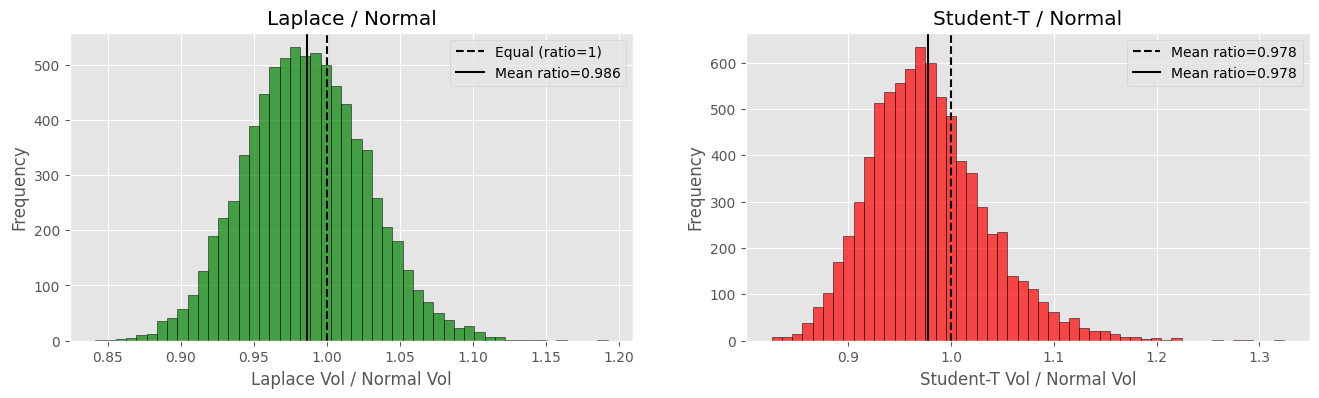

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Laplace / Normal ratio
ratio_ln = laplace_samples / normal_samples
axes[0].hist(ratio_ln, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].axvline(x=1, color='black', linestyle='--', label='Equal (ratio=1)')
axes[0].axvline(x=ratio_ln.mean(), color='black', linestyle='-', label=f'Mean ratio={ratio_ln.mean():.3f}')
axes[0].set_xlabel('Laplace Vol / Normal Vol')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Laplace / Normal')
axes[0].legend()

# Student-T / Normal ratio
ratio_sn = student_samples / normal_samples
axes[1].hist(ratio_sn, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].axvline(x=1, color='black', linestyle='--', label=f'Mean ratio={ratio_sn.mean():.3f}')
axes[1].axvline(x=ratio_sn.mean(), color='black', linestyle='-', label=f'Mean ratio={ratio_sn.mean():.3f}')
axes[1].set_xlabel('Student-T Vol / Normal Vol')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Student-T / Normal')
axes[1].legend()
